In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler

In [2]:
data = pd.read_csv("../data/kaggle_b2_fraud_train_v3.csv")

In [3]:
df = data.copy()
df

,customer_id,account_id,age,tenure_months,annual_income_eur,credit_score,num_transactions_30d,avg_amount_30d_eur,max_amount_30d_eur,days_since_last_login,...,internal_signal_5,internal_signal_6,internal_signal_7,internal_signal_8,terms_accepted_flag,partner_risk_indicator,manual_review_result,post_event_status_code,chargeback_resolution_time_days,legacy_partner_score
0,CUST_6O9Q8D4I36,ACC_TXXXTNEUVKFY,34,108,38635.01,544.0,20,60.92,80.16,4.9,...,0.39006,0.10963,0.55097,-0.56104,1,NaN,approve,0,7.9,NaN
1,CUST_FGUGTW230C,ACC_70VD7A4FFWCW,48,2,19912.97,703.0,21,112.11,571.12,0.3,...,0.03265,-0.40256,0.36218,0.86583,1,NaN,approve,0,5.5,NaN
2,CUST_8ZI3LCBZ0W,ACC_AF53381QSC0L,27,0,20326.87,720.0,25,73.61,492.57,4.6,...,-0.15637,0.57818,0.28902,-2.19864,1,NaN,approve,0,7.2,NaN
3,CUST_5MP3AR41CJ,ACC_U7WZGJ486LIV,45,49,38452.47,703.0,17,47.53,204.18,25.3,...,-1.02145,0.63908,-0.89190,-0.81592,1,NaN,approve,0,4.4,NaN
4,CUST_GNPL83JB0J,ACC_XW7DS3ED5J4Y,37,46,NaN,594.0,13,99.95,734.09,12.8,...,-0.65771,0.08020,0.17606,0.86739,1,NaN,approve,0,4.9,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159995,CUST_I81IW5SVRQ,ACC_UPDTFTYTSM0A,56,0,34775.62,727.0,21,51.72,226.11,3.8,...,-2.54086,-0.60747,0.23252,-0.06215,1,-1.535486,approve,0,1.0,NaN
159996,CUST_QT6DDEMKTJ,ACC_97NE0LBL5W9U,41,4,88617.57,770.0,18,NaN,171.07,15.1,...,0.34098,-1.78817,0.31788,0.51072,1,NaN,approve,0,7.4,NaN
159997,CUST_I0JS1GTS98,ACC_9JJ84W64Z7GX,30,2,41148.54,738.0,20,29.34,119.81,0.7,...,-1.28947,-0.32324,-0.06238,-0.99076,1,NaN,approve,3,6.6,NaN
159998,CUST_L7GUCJ3TFY,ACC_NGFXDR7HW1ZS,56,6,NaN,719.0,25,88.56,553.16,22.6,...,0.47179,-0.22090,-1.34239,-0.30513,1,NaN,approve,0,12.5,NaN


# Preprocessing KNN

## 1. Nettoyage des colonnes

In [4]:
df = df[df.columns[df.isna().sum()/df.shape[0] <0.9]]
df.head()

,customer_id,account_id,age,tenure_months,annual_income_eur,credit_score,num_transactions_30d,avg_amount_30d_eur,max_amount_30d_eur,days_since_last_login,...,internal_signal_3,internal_signal_4,internal_signal_5,internal_signal_6,internal_signal_7,internal_signal_8,terms_accepted_flag,manual_review_result,post_event_status_code,chargeback_resolution_time_days
0,CUST_6O9Q8D4I36,ACC_TXXXTNEUVKFY,34,108,38635.01,544.0,20,60.92,80.16,4.9,...,-0.68676,-1.54627,0.39006,0.10963,0.55097,-0.56104,1,approve,0,7.9
1,CUST_FGUGTW230C,ACC_70VD7A4FFWCW,48,2,19912.97,703.0,21,112.11,571.12,0.3,...,-0.17429,-0.00054,0.03265,-0.40256,0.36218,0.86583,1,approve,0,5.5
2,CUST_8ZI3LCBZ0W,ACC_AF53381QSC0L,27,0,20326.87,720.0,25,73.61,492.57,4.6,...,-0.86064,-0.32183,-0.15637,0.57818,0.28902,-2.19864,1,approve,0,7.2
3,CUST_5MP3AR41CJ,ACC_U7WZGJ486LIV,45,49,38452.47,703.0,17,47.53,204.18,25.3,...,-1.11761,1.35968,-1.02145,0.63908,-0.89190,-0.81592,1,approve,0,4.4
4,CUST_GNPL83JB0J,ACC_XW7DS3ED5J4Y,37,46,NaN,594.0,13,99.95,734.09,12.8,...,0.11581,1.65795,-0.65771,0.08020,0.17606,0.86739,1,approve,0,4.9


In [5]:
df = df.drop(columns=["account_id"]) # N'apporte pas d'informations pour les futurs modèles

In [6]:
df = df.drop(columns=["customer_note"]) # Contient une série de mot libre qui ne nous eet pas pendant le preprocess

In [27]:
df

,customer_id,age,tenure_months,annual_income_eur,credit_score,num_transactions_30d,avg_amount_30d_eur,max_amount_30d_eur,days_since_last_login,support_tickets_90d,...,internal_signal_3,internal_signal_4,internal_signal_5,internal_signal_6,internal_signal_7,internal_signal_8,terms_accepted_flag,manual_review_result,post_event_status_code,chargeback_resolution_time_days
115911,CUST_HWG8RQ0VF0,34,45,27572.37,829.0,26,167.35,800.54,5.2,1,...,-1.02057,-0.82146,-1.43762,0.10419,0.30952,0.07830,1,approve,0,3.2
18471,CUST_6ME30M921E,44,3,37316.20,628.0,18,125.94,995.64,30.3,0,...,-0.15087,-0.04788,-0.19457,-0.18479,-0.38806,-0.55880,1,approve,0,11.0
48519,CUST_323EN2SNMU,29,9,94389.99,661.0,24,8.14,48.34,9.0,0,...,-0.05450,0.67783,-0.03505,-0.24812,-0.40885,0.42355,1,approve,0,7.8
93373,CUST_WFJLLYXMOZ,46,58,47033.18,511.0,25,35.30,219.78,34.3,0,...,1.24965,1.80149,-0.04143,1.11628,1.25989,1.42511,1,approve,0,0.0
159852,CUST_1Z8LKDI70G,18,8,45746.40,669.0,33,72.49,114.93,4.5,1,...,-0.02424,-1.10382,-0.96914,-0.43220,0.35714,-0.93083,1,review,0,0.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79938,CUST_K100QZMNN2,43,53,23339.03,785.0,16,26.67,45.59,33.4,1,...,-0.13688,-0.85524,0.92306,0.37753,0.08758,0.31478,1,approve,0,14.4
55835,CUST_QMHTARFSQP,41,9,13426.52,681.0,19,1.99,NaN,10.8,0,...,1.37606,-0.18912,0.19047,0.01050,0.92194,-0.06246,1,approve,0,14.9
42846,CUST_S3QNAR2VT9,39,20,14171.96,736.0,29,63.11,NaN,3.0,0,...,-0.15809,0.41068,-0.75914,-0.84245,0.32793,-0.85109,1,approve,0,1.3
96511,CUST_IZO6DIZHT6,43,1,91308.90,633.0,15,99.19,443.88,5.6,1,...,-0.23943,-0.57388,-1.61995,-0.70567,0.37588,-0.76732,1,approve,0,11.9


                         income_log  annual_income_eur  \
income_log                 1.000000           0.763881   
annual_income_eur          0.763881           1.000000   
income_estimate_alt_eur    0.925534           0.822232   

                         income_estimate_alt_eur  
income_log                              0.925534  
annual_income_eur                       0.822232  
income_estimate_alt_eur                 1.000000  


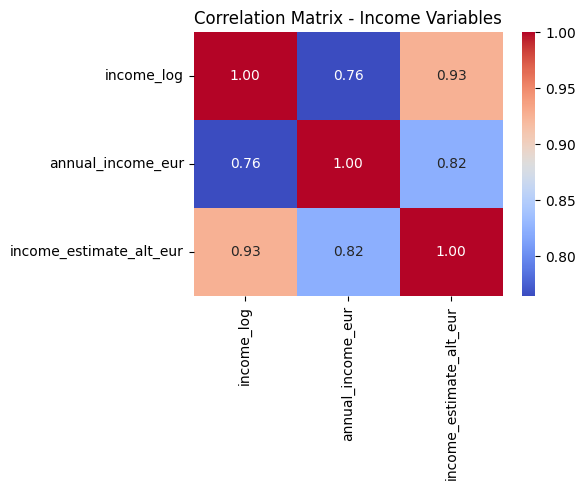

In [ ]:
cols = [
    "income_log",
    "annual_income_eur",
    "income_estimate_alt_eur"
]

corr_matrix = df[cols].corr(method="pearson")

print(corr_matrix)

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix - Income Variables")
plt.tight_layout()
plt.show()

In [8]:
df = df.drop(columns=["income_estimate_alt_eur"])

## 2. Split Temporel

In [9]:
df = df.sort_values("signup_date")
split_index = int(len(df) * 0.8)
train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

# Séparer target
target = "target_is_fraud"
y_train = train_df[target].copy()
y_test = test_df[target].copy()

# Conserver customer_id
customer_train = train_df[["customer_id"]].copy()
customer_test = test_df[["customer_id"]].copy()

# Drop target et customer_id pour preprocessing
X_train = train_df.drop(columns=[target, "customer_id"])
X_test = test_df.drop(columns=[target, "customer_id"])


## 3. Imputation

In [10]:
num_cols = X_train.select_dtypes(include=["int64","float64"]).columns
cat_cols = X_train.select_dtypes(include=["object","category"]).columns

In [11]:
medians = X_train[num_cols].median()
X_train[num_cols] = X_train[num_cols].fillna(medians)
X_test[num_cols] = X_test[num_cols].fillna(medians)


In [12]:
X_train[cat_cols] = X_train[cat_cols].fillna("MISSING")
X_test[cat_cols] = X_test[cat_cols].fillna("MISSING")

## 4. Target Encoding

In [13]:
global_mean = y_train.mean()
min_samples = 50
smoothing = 10

target_means = {}

for col in cat_cols:
    # Moyennes par catégorie sur le train
    stats = y_train.groupby(X_train[col]).agg(["count","mean"])
    smooth = 1 / (1 + np.exp(-(stats["count"] - min_samples)/smoothing))
    means = global_mean * (1 - smooth) + stats["mean"] * smooth
    target_means[col] = means.to_dict()
    
    # Appliquer sur train
    X_train[col + "_te"] = X_train[col].map(target_means[col])
    
    # Appliquer sur test
    X_test[col + "_te"] = X_test[col].map(target_means[col])
    X_test[col + "_te"] = X_test[col + "_te"].fillna(global_mean)


In [14]:
X_train = X_train.drop(columns=cat_cols)
X_test = X_test.drop(columns=cat_cols)

## 5. Scaling

In [15]:
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


In [21]:
X_train_export = X_train.copy()
X_train_export["customer_id"] = customer_train["customer_id"]
X_train_export["target_is_fraud"] = y_train

X_test_export = X_test.copy()
X_test_export["customer_id"] = customer_test["customer_id"]

# Réordonner colonnes si besoin
cols_train = ["customer_id", "target_is_fraud"] + [c for c in X_train_export.columns if c not in ["customer_id","target_is_fraud"]]
X_train_export = X_train_export[cols_train]


In [25]:
X_train_export.to_csv("../data/data_preprocess_train_v1.csv")

In [26]:
X_test_export.to_csv("../data/data_preprocess_test_v1.csv")

In [22]:
X_train_export

,customer_id,target_is_fraud,age,tenure_months,annual_income_eur,credit_score,num_transactions_30d,avg_amount_30d_eur,max_amount_30d_eur,days_since_last_login,...,occupation_te,device_type_te,merchant_category_te,country_te,region_te,city_te,last_ticket_subject_te,referrer_code_te,signup_date_te,manual_review_result_te
115911,CUST_HWG8RQ0VF0,0,-0.359004,1.523721,-0.366958,2.717860,0.083988,2.617560,2.019244,-0.565847,...,0.031029,0.030998,0.031883,0.031353,0.032106,0.030981,0.026822,0.030523,0.004484,0.001797
18471,CUST_6ME30M921E,0,0.491365,-0.839563,0.003657,-0.716133,-0.137925,1.597023,2.798874,1.524519,...,0.031029,0.030998,0.029784,0.031353,0.032106,0.024634,0.031046,0.030523,0.004484,0.001797
48519,CUST_323EN2SNMU,0,-0.784188,-0.501951,2.174505,-0.152343,0.028509,-1.306123,-0.986590,-0.249377,...,0.029221,0.030998,0.032750,0.031353,0.030207,0.024371,0.033182,0.030523,0.004484,0.001797
93373,CUST_WFJLLYXMOZ,0,0.661438,2.255214,0.373250,-2.715024,0.056248,-0.636773,-0.301506,1.857645,...,0.031029,0.030998,0.031883,0.031353,0.029891,0.023841,0.035165,0.030523,0.004484,0.001797
159852,CUST_1Z8LKDI70G,0,-1.719593,-0.558220,0.324306,-0.015667,0.278161,0.279763,-0.720492,-0.624144,...,0.031029,0.030998,0.028930,0.031353,0.031826,0.030303,0.033182,0.030523,0.004484,0.029707
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95678,CUST_AZLUHUU2PO,0,1.001586,-0.670757,1.165113,1.863633,0.222683,0.794098,-0.281545,-0.316002,...,0.029280,0.025974,0.032750,0.029796,0.029220,0.032070,0.033182,0.030523,0.029146,0.029707
14656,CUST_DMR5U29RAQ,0,-0.444040,-0.839563,-0.715940,0.616461,-0.110186,-0.209434,1.205207,1.016502,...,0.029280,0.030998,0.032750,0.031353,0.032106,0.035923,0.028625,0.030523,0.029146,0.001797
14565,CUST_2O9M1IGECI,0,-0.359004,1.805065,-0.424538,0.838560,-0.026969,-0.794006,-0.269497,-0.882317,...,0.028638,0.030428,0.028930,0.031353,0.030681,0.030120,0.022973,0.030523,0.029146,0.001797
103500,CUST_J8UJPMPKHT,0,-0.018856,1.073572,2.652226,-0.596541,-0.137925,-0.596602,0.005351,0.525141,...,0.028638,0.030727,0.031283,0.027823,0.029220,0.029895,0.033182,0.030523,0.029146,0.001797


In [24]:
X_test_export

,age,tenure_months,annual_income_eur,credit_score,num_transactions_30d,avg_amount_30d_eur,max_amount_30d_eur,days_since_last_login,support_tickets_90d,chargebacks_12m,...,device_type_te,merchant_category_te,country_te,region_te,city_te,last_ticket_subject_te,referrer_code_te,signup_date_te,manual_review_result_te,customer_id
15273,-0.018856,-0.389414,1.300338,-0.835725,0.139466,-0.732395,-0.199447,-0.824020,1.341507,-0.223948,...,0.030998,0.032750,0.031353,0.030207,0.035771,0.033182,0.03075,0.029146,0.029707,CUST_925MSOFELP
133842,0.491365,1.073572,-0.201193,-0.835725,0.028509,-1.175753,-0.758894,-0.882317,1.341507,-0.223948,...,0.030998,0.031283,0.031353,0.032106,0.031327,0.031046,0.03075,0.029146,0.551891,CUST_PTGSLVG75B
44927,0.151217,1.298647,-0.562247,0.667715,0.083988,-0.240240,-0.281545,-0.890645,0.224806,-0.223948,...,0.030998,0.028930,0.031353,0.029891,0.023841,0.033182,0.03075,0.029146,0.001797,CUST_S6ERZCDY77
83817,0.151217,0.060736,0.396121,-0.972401,-0.221143,-1.044643,-0.637294,-0.632472,0.224806,-0.223948,...,0.030998,0.028930,0.031353,0.028478,0.024327,0.022973,0.03075,0.029146,0.029707,CUST_7XFAN8C8LI
107431,-0.018856,0.060736,-0.201193,-0.084005,-0.054708,0.432560,-0.257989,1.041486,-0.891895,-0.223948,...,0.030998,0.032750,0.031353,0.033846,0.033493,0.031046,0.03075,0.029146,0.029707,CUST_8AO6C6Q06I
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79938,0.406328,1.973871,-0.527976,1.966140,-0.193404,-0.849457,-0.997579,1.782692,0.224806,-0.223948,...,0.030695,0.032837,0.029796,0.029220,0.029632,0.028625,0.03075,0.030750,0.001797,CUST_K100QZMNN2
55835,0.236254,-0.501951,-0.905006,0.189348,-0.110186,-1.457688,-0.281545,-0.099470,-0.891895,-0.223948,...,0.030428,0.029576,0.029796,0.029220,0.025303,0.033101,0.03075,0.030750,0.001797,CUST_QMHTARFSQP
42846,0.066181,0.117005,-0.876653,1.128997,0.167205,0.048596,-0.281545,-0.749066,-0.891895,-0.223948,...,0.030998,0.032837,0.031353,0.032298,0.035853,0.031046,0.03075,0.030750,0.001797,CUST_S3QNAR2VT9
96511,0.406328,-0.952100,2.057313,-0.630710,-0.221143,0.937777,0.594010,-0.532534,0.224806,-0.223948,...,0.030998,0.028930,0.031353,0.031510,0.036077,0.022973,0.03075,0.030750,0.001797,CUST_IZO6DIZHT6
